Feature matrix: (2008, 116)
Positive class rate (deaths within 28 days): 0.0184

Training logistic regression...
  epoch    0  weighted log-loss = 0.6931
  epoch  500  weighted log-loss = 0.0546
  epoch 1000  weighted log-loss = 0.0389
  epoch 1500  weighted log-loss = 0.0316
  epoch 2000  weighted log-loss = 0.0271
  epoch 2500  weighted log-loss = 0.0238

Confusion matrix:
           Pred 0   Pred 1
Actual 0      369       25
Actual 1        2        5

Accuracy:  0.933
Precision: 0.167
Recall:    0.714
F1 score:  0.270
ROC-AUC:   0.828


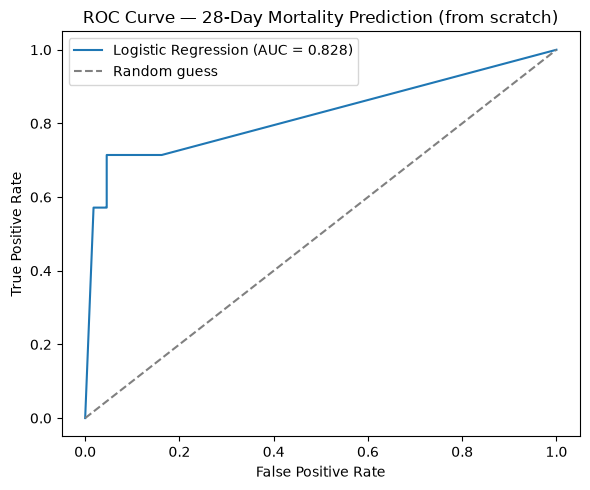


Top 15 features by |coefficient| (standardized scale):
                            feature  coefficient
            heart_failure_type_both    -2.249869
                       killip_grade     2.143744
respiratory_failure_type2_nontypeii    -2.142097
                       homocysteine    -2.109319
                        hs_troponin    -1.893693
                          intercept    -1.836153
                       nucleotidase    -1.750073
           admission_mode_Emergency    -1.617017
                     platelet_count     1.585438
                       diastolic_bp     1.532785
           oxygen_use_OxygenTherapy    -1.474830
                 age_category_69-79    -1.429207
                consciousness_Clear    -1.362266
                         hemiplegia    -1.292060
                        eye_opening    -1.273937


In [ ]:
"""
Predict 28-day mortality (mortality_28d) from the merged heart failure dataset
WITHOUT scikit-learn — logistic regression implemented from scratch using
only pandas, numpy and matplotlib.

Input: cleaned_files/heart_failure_merged.csv
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =================================================================
# 1. Load data
# =================================================================
df = pd.read_csv("cleaned_files/heart_failure_merged.csv")
TARGET = "mortality_28d"

# =================================================================
# 2. Drop leakage / non-predictive columns
#    (same reasoning as before: other outcome columns, discharge
#    fields determined after the fact, IDs, free text, QC artifacts)
# =================================================================
leak_or_id_cols = [
    "patient_id", "discharge_destination", "admission_ward",
    "discharge_department", "discharge_day", "admission_date",
    "in_hosp_outcome", "readmission_28d", "death_3mo", "readmission_3mo",
    "mortality_3mo", "readmission_6mo", "death_time_days",
    "readmission_time_days", "ed_return_6mo", "ed_return_time_days",
    "drugs_list", "bmi_original", "measurement",
]
df = df.drop(columns=[c for c in leak_or_id_cols if c in df.columns])
df = df.dropna(subset=[TARGET])

y = df[TARGET].astype(int).values
X = df.drop(columns=[TARGET]).copy()

print("Feature matrix:", X.shape)
print("Positive class rate (deaths within 28 days):", round(y.mean(), 4))

# =================================================================
# 3. Identify column types & fill categorical NaNs with a placeholder
# =================================================================
categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in categorical_cols:
    X[col] = X[col].astype("string").fillna("Unknown")

# =================================================================
# 4. One-hot encode categorical columns (pandas get_dummies — no sklearn)
# =================================================================
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)
feature_names = X_encoded.columns.tolist()
X_values = X_encoded.to_numpy(dtype=float)

# =================================================================
# 5. Stratified train/test split (manual, no sklearn)
# =================================================================
def stratified_split(y, test_size=0.2, seed=42):
    rng = np.random.default_rng(seed)
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    rng.shuffle(idx_pos)
    rng.shuffle(idx_neg)
    n_pos_test = max(1, int(len(idx_pos) * test_size))
    n_neg_test = int(len(idx_neg) * test_size)
    test_idx = np.concatenate([idx_pos[:n_pos_test], idx_neg[:n_neg_test]])
    train_idx = np.concatenate([idx_pos[n_pos_test:], idx_neg[n_neg_test:]])
    rng.shuffle(train_idx)
    rng.shuffle(test_idx)
    return train_idx, test_idx

train_idx, test_idx = stratified_split(y, test_size=0.2, seed=42)
X_train_raw, X_test_raw = X_values[train_idx], X_values[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# =================================================================
# 6. Impute missing numeric values using TRAIN medians only
#    (keeps test-set information from leaking into training)
# =================================================================
numeric_positions = [feature_names.index(c) for c in numeric_cols]

for pos in numeric_positions:
    median_val = np.nanmedian(X_train_raw[:, pos])
    X_train_raw[np.isnan(X_train_raw[:, pos]), pos] = median_val
    X_test_raw[np.isnan(X_test_raw[:, pos]), pos] = median_val

# =================================================================
# 7. Standardize numeric columns using TRAIN mean/std
#    (one-hot dummy columns are left as 0/1, unscaled)
# =================================================================
for pos in numeric_positions:
    mean_val = X_train_raw[:, pos].mean()
    std_val = X_train_raw[:, pos].std()
    std_val = std_val if std_val > 1e-8 else 1.0
    X_train_raw[:, pos] = (X_train_raw[:, pos] - mean_val) / std_val
    X_test_raw[:, pos] = (X_test_raw[:, pos] - mean_val) / std_val

# =================================================================
# 8. Add intercept (bias) column
# =================================================================
X_train = np.hstack([np.ones((X_train_raw.shape[0], 1)), X_train_raw])
X_test = np.hstack([np.ones((X_test_raw.shape[0], 1)), X_test_raw])
all_feature_names = ["intercept"] + feature_names

# =================================================================
# 9. Logistic regression from scratch (batch gradient descent)
#    Class weighting mimics sklearn's class_weight="balanced":
#    the rare positive class gets a bigger weight in the loss.
# =================================================================
def sigmoid(z):
    z = np.clip(z, -500, 500)  # avoid overflow
    return 1.0 / (1.0 + np.exp(-z))

def train_logistic_regression(X, y, lr=0.3, epochs=3000, l2=0.01):
    n, d = X.shape
    theta = np.zeros(d)

    n_pos = y.sum()
    n_neg = n - n_pos
    w_pos = n / (2.0 * n_pos)
    w_neg = n / (2.0 * n_neg)
    sample_weights = np.where(y == 1, w_pos, w_neg)

    for epoch in range(epochs):
        z = X.dot(theta)
        p = sigmoid(z)
        error = sample_weights * (p - y)
        grad = X.T.dot(error) / n
        grad[1:] += (l2 / n) * theta[1:]   # don't regularize the intercept
        theta -= lr * grad

        if epoch % 500 == 0:
            eps = 1e-9
            loss = -np.mean(sample_weights * (y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)))
            print(f"  epoch {epoch:4d}  weighted log-loss = {loss:.4f}")

    return theta

print("\nTraining logistic regression...")
theta = train_logistic_regression(X_train, y_train, lr=0.3, epochs=3000, l2=0.01)

# =================================================================
# 10. Predict on the test set
# =================================================================
y_proba = sigmoid(X_test.dot(theta))
y_pred = (y_proba >= 0.5).astype(int)

# =================================================================
# 11. Evaluation metrics (all computed manually, no sklearn)
# =================================================================
tp = np.sum((y_pred == 1) & (y_test == 1))
tn = np.sum((y_pred == 0) & (y_test == 0))
fp = np.sum((y_pred == 1) & (y_test == 0))
fn = np.sum((y_pred == 0) & (y_test == 1))

accuracy = (tp + tn) / len(y_test)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

print("\nConfusion matrix:")
print(f"           Pred 0   Pred 1")
print(f"Actual 0   {tn:6d}   {fp:6d}")
print(f"Actual 1   {fn:6d}   {tp:6d}")

print(f"\nAccuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 score:  {f1:.3f}")

# ROC-AUC via the Mann-Whitney U statistic (rank-based, no sklearn needed)
def roc_auc_manual(y_true, y_score):
    order = np.argsort(y_score)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(y_score) + 1)
    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos
    sum_ranks_pos = ranks[y_true == 1].sum()
    auc = (sum_ranks_pos - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
    return auc

auc = roc_auc_manual(y_test, y_proba)
print(f"ROC-AUC:   {auc:.3f}")

# =================================================================
# 12. Plot ROC curve manually (threshold sweep)
# =================================================================
thresholds = np.linspace(0, 1, 101)
tpr_list, fpr_list = [], []
for t in thresholds:
    pred_t = (y_proba >= t).astype(int)
    tp_t = np.sum((pred_t == 1) & (y_test == 1))
    fn_t = np.sum((pred_t == 0) & (y_test == 1))
    fp_t = np.sum((pred_t == 1) & (y_test == 0))
    tn_t = np.sum((pred_t == 0) & (y_test == 0))
    tpr_list.append(tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0)
    fpr_list.append(fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0.0)

plt.figure(figsize=(6, 5))
plt.plot(fpr_list, tpr_list, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — 28-Day Mortality Prediction (from scratch)")
plt.legend()
plt.tight_layout()
plt.savefig("mortality_28d_roc_curve_scratch.png", dpi=150)
plt.show()

# =================================================================
# 13. Top features by |coefficient| (standardized scale)
# =================================================================
coef_df = (
    pd.DataFrame({"feature": all_feature_names, "coefficient": theta})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .head(15)
)

print("\nTop 15 features by |coefficient| (standardized scale):")
print(coef_df[["feature", "coefficient"]].to_string(index=False))